In [18]:
import matplotlib.pyplot as plt
import numpy as np

gpt54_path = "results/eval_5-4.txt"
gpt4o_path = "results/eval_4o.txt"

qwen2_path = "training/results/eval_2b_20epoch.txt"
qwen4_path = "training/results/eval_4b_trained.txt"
qwen8_path = "training/results/eval_8b_trained.txt"


In [7]:
def extract(path):
    items = {}

    with open(path, 'r', encoding='utf-8') as vstup:

        for radek in vstup:
            if ':' in radek:
                row = radek.split(':')
                if row[0] == 'Directories':
                    continue

                row[1] = row[1].strip()
                items[row[0]] = float(row[1])

    return items

gpt54 = extract(gpt54_path)
gpt4o = extract(gpt4o_path)

qwen2 = extract(qwen2_path)
qwen4 = extract(qwen4_path)
qwen8 = extract(qwen8_path)
qwen8

{'Number of files': 118.0,
 'Valid files ratio': 0.9830508474576272,
 'Names CER': 0.16894497020679985,
 'Chapter numbers CER': 0.2700348432055749,
 'Page numbers CER': 0.1492063492063492,
 'Descriptions CER': 0.5613122983148082,
 'Names bbox f1_score': 0.8196816208393632,
 'Names bbox mean iou': 0.8814877271652222,
 'Chapter numbers bbox f1_score': 0.4628632938643703,
 'Chapter numbers bbox mean iou': 0.8334506154060364,
 'Page numbers bbox f1_score': 0.6208635360857233,
 'Page numbers bbox mean iou': 0.8518961668014526,
 'Descriptions bbox f1_score': 0.36363636363636365,
 'Descriptions bbox mean iou': 0.9030137658119202,
 'Structure chapters f1_score': 0.7674929400690303,
 'Structure page number accuracy': 0.8318296721881563,
 'Structure chap number accuracy': 0.7803684812309288,
 'Structure description accuracy': 0.44499013351667965}

In [8]:
file_data = ['Number of files', 'Valid files ratio']
text_data = ['Names CER', 'Chapter numbers CER', 'Page numbers CER', 'Descriptions CER']
bbox_data_f1 = ['Names bbox f1_score', 'Chapter numbers bbox f1_score', 'Page numbers bbox f1_score', 'Descriptions bbox f1_score']
bbox_data_iou = ['Names bbox mean iou', 'Chapter numbers bbox mean iou', 'Page numbers bbox mean iou', 'Descriptions bbox mean iou']
struct_data = [ 'Structure chapters f1_score', 'Structure page number accuracy', 'Structure chap number accuracy', 'Structure description accuracy']

In [ ]:
{k: v for k, v in gpt54.items() if k in file_data}, {k: v for k, v in gpt4o.items() if k in file_data}

({'Number of files': 399.0, 'Valid files ratio': 0.9974937343358395},
 {'Number of files': 1391.0, 'Valid files ratio': 0.9985621854780733})

In [ ]:
{k: v for k, v in qwen2.items() if k in file_data}, {k: v for k, v in qwen4.items() if k in file_data}, {k: v for k, v in qwen8.items() if k in file_data}

({'Number of files': 111.0, 'Valid files ratio': 0.918918918918919},
 {'Number of files': 130.0, 'Valid files ratio': 0.9692307692307692},
 {'Number of files': 118.0, 'Valid files ratio': 0.9830508474576272})

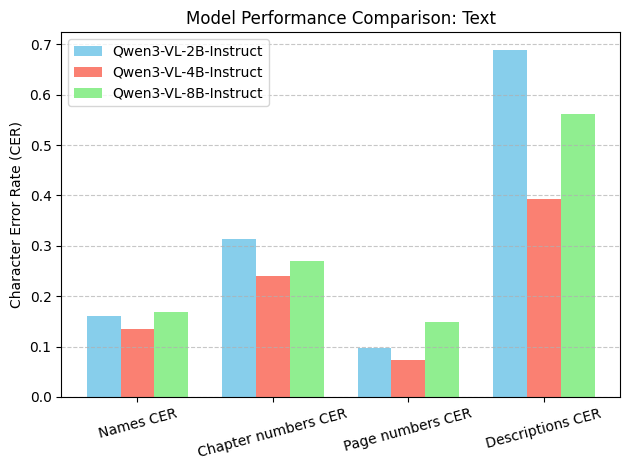

In [ ]:

qwen2_text = {k: v for k, v in qwen2.items() if k in text_data}
qwen4_text = {k: v for k, v in qwen4.items() if k in text_data}
qwen8_text = {k: v for k, v in qwen8.items() if k in text_data}


labels = list(qwen2_text.keys())
values_qwen2 = list(qwen2_text.values())
values_qwen4 = list(qwen4_text.values())
values_qwen8 = list(qwen8_text.values())

x = np.arange(len(labels))

# Zúžíme sloupce. 3 * 0.25 = 0.75, takže zbyde 0.25 jako mezera mezi skupinami
width = 0.25

# Vykreslení 3 sloupců s upraveným posunem (-width, 0, +width)
plt.bar(x - width, values_qwen2, width, label='Qwen3-VL-2B-Instruct', color='skyblue')
plt.bar(x, values_qwen4, width, label='Qwen3-VL-4B-Instruct', color='salmon')
plt.bar(x + width, values_qwen8, width, label='Qwen3-VL-8B-Instruct', color='lightgreen') # Zde uprav popisek a barvu

plt.ylabel('Character Error Rate (CER)')
plt.title('Model Performance Comparison: Text')
plt.xticks(x, labels, rotation=15)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Uložení a zobrazení
plt.savefig("graphs/qwen_text.pdf")
plt.show()

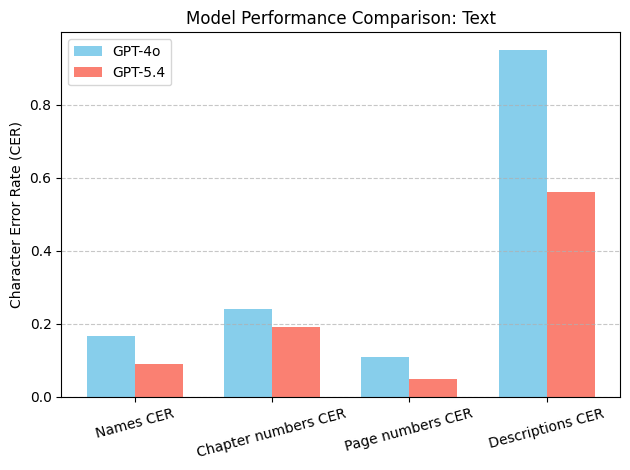

In [30]:

gpt4o_text = {k: v for k, v in gpt4o.items() if k in text_data}
gpt54_text = {k: v for k, v in gpt54.items() if k in text_data}

labels = list(gpt4o_text.keys())
values_gpt4o = list(gpt4o_text.values())
values_gpt54 = list(gpt54_text.values())

x = np.arange(len(labels))

width = 0.35

# Vykreslení grafu s posunem
plt.bar(x - width/2, values_gpt4o, width, label='GPT-4o', color='skyblue')
plt.bar(x + width/2, values_gpt54, width, label='GPT-5.4', color='salmon')

plt.ylabel('Character Error Rate (CER)')
plt.title('Model Performance Comparison: Text')
plt.xticks(x, labels, rotation=15)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("graphs/gpt_text.pdf")
plt.show()

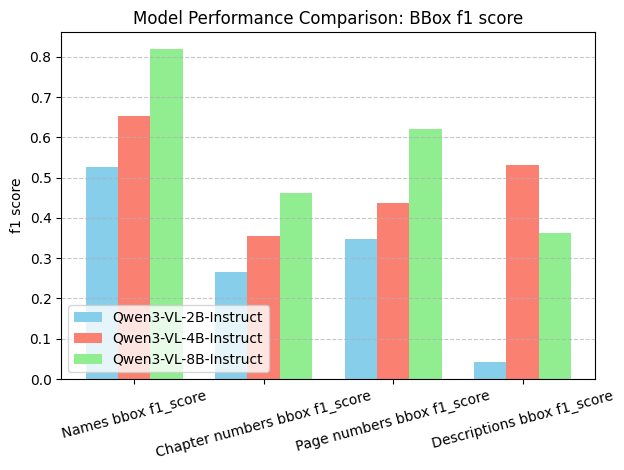

In [41]:


qwen2_text = {k: v for k, v in qwen2.items() if k in bbox_data_f1}
qwen4_text = {k: v for k, v in qwen4.items() if k in bbox_data_f1}
qwen8_text = {k: v for k, v in qwen8.items() if k in bbox_data_f1}


labels = list(qwen2_text.keys())
values_qwen2 = list(qwen2_text.values())
values_qwen4 = list(qwen4_text.values())
values_qwen8 = list(qwen8_text.values())

x = np.arange(len(labels))

# Zúžíme sloupce. 3 * 0.25 = 0.75, takže zbyde 0.25 jako mezera mezi skupinami
width = 0.25

# Vykreslení 3 sloupců s upraveným posunem (-width, 0, +width)
plt.bar(x - width, values_qwen2, width, label='Qwen3-VL-2B-Instruct', color='skyblue')
plt.bar(x, values_qwen4, width, label='Qwen3-VL-4B-Instruct', color='salmon')
plt.bar(x + width, values_qwen8, width, label='Qwen3-VL-8B-Instruct', color='lightgreen') # Zde uprav popisek a barvu

plt.ylabel('f1 score')
plt.title('Model Performance Comparison: BBox f1 score')
plt.xticks(x, labels, rotation=15)
plt.legend(loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Uložení a zobrazení
plt.savefig("graphs/qwen_bbox_f1.pdf")
plt.show()

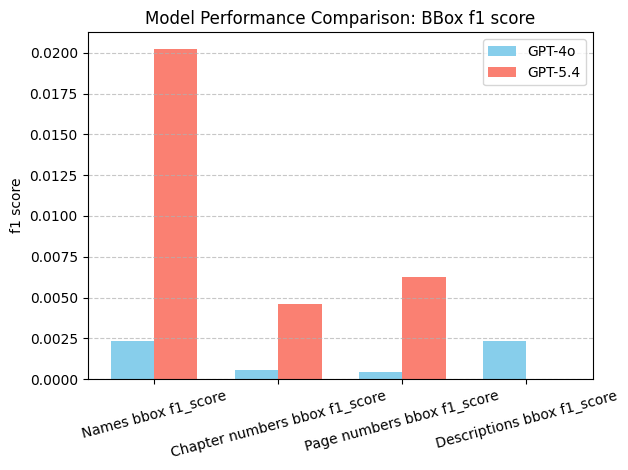

In [27]:

gpt4o_bbox_f1 = {k: v for k, v in gpt4o.items() if k in bbox_data_f1}
gpt54_bbox_f1 = {k: v for k, v in gpt54.items() if k in bbox_data_f1}

labels = list(gpt4o_bbox_f1.keys())
values_gpt4o = list(gpt4o_bbox_f1.values())
values_gpt54 = list(gpt54_bbox_f1.values())

x = np.arange(len(labels))

width = 0.35

# Vykreslení grafu s posunem
plt.bar(x - width/2, values_gpt4o, width, label='GPT-4o', color='skyblue')
plt.bar(x + width/2, values_gpt54, width, label='GPT-5.4', color='salmon')

plt.ylabel('f1 score')
plt.title('Model Performance Comparison: BBox f1 score')
plt.xticks(x, labels, rotation=15)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("graphs/gpt_bbox_f1.pdf")
plt.show()

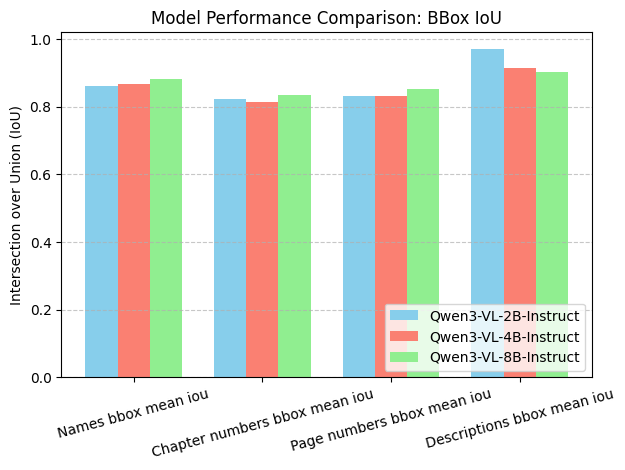

In [42]:
qwen2_text = {k: v for k, v in qwen2.items() if k in bbox_data_iou}
qwen4_text = {k: v for k, v in qwen4.items() if k in bbox_data_iou}
qwen8_text = {k: v for k, v in qwen8.items() if k in bbox_data_iou}


labels = list(qwen2_text.keys())
values_qwen2 = list(qwen2_text.values())
values_qwen4 = list(qwen4_text.values())
values_qwen8 = list(qwen8_text.values())

x = np.arange(len(labels))

# Zúžíme sloupce. 3 * 0.25 = 0.75, takže zbyde 0.25 jako mezera mezi skupinami
width = 0.25

# Vykreslení 3 sloupců s upraveným posunem (-width, 0, +width)
plt.bar(x - width, values_qwen2, width, label='Qwen3-VL-2B-Instruct', color='skyblue')
plt.bar(x, values_qwen4, width, label='Qwen3-VL-4B-Instruct', color='salmon')
plt.bar(x + width, values_qwen8, width, label='Qwen3-VL-8B-Instruct', color='lightgreen') # Zde uprav popisek a barvu

plt.ylabel('Intersection over Union (IoU)')
plt.title('Model Performance Comparison: BBox IoU')
plt.xticks(x, labels, rotation=15)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Uložení a zobrazení
plt.savefig("graphs/qwen_bbox_iou.pdf")
plt.show()

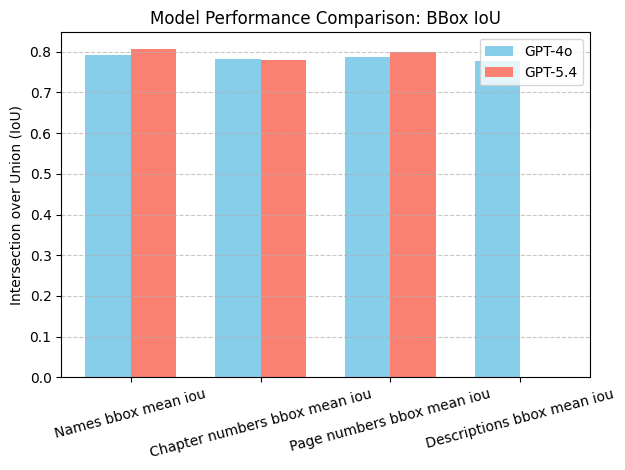

In [26]:
gpt4o_bbox_iou = {k: v for k, v in gpt4o.items() if k in bbox_data_iou}
gpt54_bbox_iou = {k: v for k, v in gpt54.items() if k in bbox_data_iou}


labels = list(gpt4o_bbox_iou.keys())
values_gpt4o = list(gpt4o_bbox_iou.values())
values_gpt54 = list(gpt54_bbox_iou.values())

x = np.arange(len(labels))

width = 0.35

# Vykreslení grafu s posunem
plt.bar(x - width/2, values_gpt4o, width, label='GPT-4o', color='skyblue')
plt.bar(x + width/2, values_gpt54, width, label='GPT-5.4', color='salmon')

plt.ylabel('Intersection over Union (IoU)')
plt.title('Model Performance Comparison: BBox IoU')
plt.xticks(x, labels, rotation=15)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("graphs/gpt_bbox_iou.pdf")

plt.show()

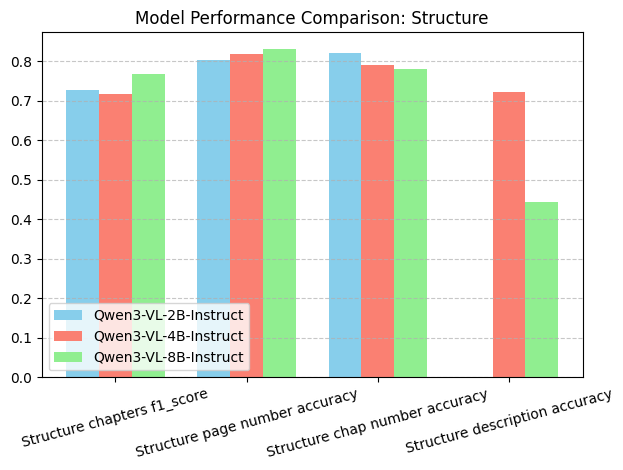

In [44]:
qwen2_text = {k: v for k, v in qwen2.items() if k in struct_data}
qwen4_text = {k: v for k, v in qwen4.items() if k in struct_data}
qwen8_text = {k: v for k, v in qwen8.items() if k in struct_data}


labels = list(qwen2_text.keys())
values_qwen2 = list(qwen2_text.values())
values_qwen4 = list(qwen4_text.values())
values_qwen8 = list(qwen8_text.values())

x = np.arange(len(labels))

# Zúžíme sloupce. 3 * 0.25 = 0.75, takže zbyde 0.25 jako mezera mezi skupinami
width = 0.25

# Vykreslení 3 sloupců s upraveným posunem (-width, 0, +width)
plt.bar(x - width, values_qwen2, width, label='Qwen3-VL-2B-Instruct', color='skyblue')
plt.bar(x, values_qwen4, width, label='Qwen3-VL-4B-Instruct', color='salmon')
plt.bar(x + width, values_qwen8, width, label='Qwen3-VL-8B-Instruct', color='lightgreen') # Zde uprav popisek a barvu

plt.title('Model Performance Comparison: Structure')
plt.xticks(x, labels, rotation=15)
plt.legend(loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Uložení a zobrazení
plt.savefig("graphs/qwen_struct.pdf")
plt.show()

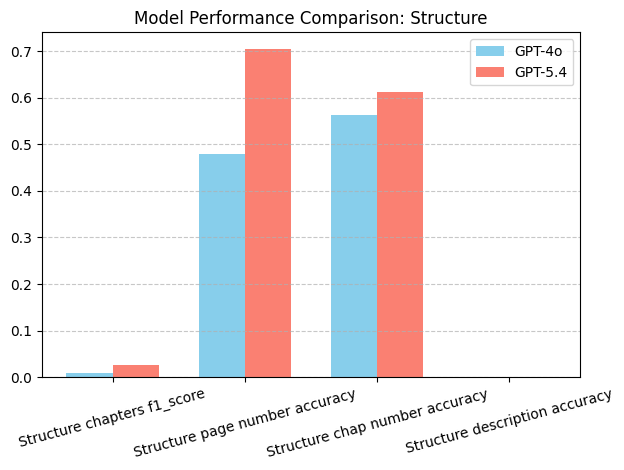

In [25]:
gpt4o_struct = {k: v for k, v in gpt4o.items() if k in struct_data}
gpt54_struct = {k: v for k, v in gpt54.items() if k in struct_data}


labels = list(gpt4o_struct.keys())
values_gpt4o = list(gpt4o_struct.values())
values_gpt54 = list(gpt54_struct.values())

x = np.arange(len(labels))

width = 0.35

# Vykreslení grafu s posunem
plt.bar(x - width/2, values_gpt4o, width, label='GPT-4o', color='skyblue')
plt.bar(x + width/2, values_gpt54, width, label='GPT-5.4', color='salmon')

plt.title('Model Performance Comparison: Structure')
plt.xticks(x, labels, rotation=15)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("graphs/gpt_struct.pdf")

plt.show()